In [1]:
!pip install -r requirements.txt

ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'


# Task 3 — Model Comparison, Selection & Saving
### Uber Fare Prediction | Parts A & B

This notebook trains **four regression models** on the same preprocessed data, compares them on the
**held-out test set** (MAE, RMSE, R²), selects one with evidence, and saves it for the Flask app.

**Why a shared `uber_pipeline.py`?** The feature engineering (distance, bearing, airport distances, cyclical
hour, ...) and the Task 2 preprocessing (winsorize → encode → scale → log-target) live in one module that
both this notebook *and* `app.py` import. That guarantees a user's raw form input goes through exactly the
same steps as the training data — the single most common reason deployed models silently predict wrong.

**Run order:** run every cell top to bottom from the project folder. It creates `uber_fare_model.pkl`,
`uber_fare_preprocessor.pkl` and `model_meta.json`, which `app.py` needs.


In [2]:
import json, time, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import uber_pipeline as up

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42

DATA_PATH = 'final_internship_data.csv'
if not os.path.exists(DATA_PATH):
    DATA_PATH = '/content/final_internship_data.csv.csv'   # Colab fallback
df_raw = pd.read_csv(DATA_PATH)
print('Raw shape:', df_raw.shape)


Raw shape: (24502, 26)


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## 1. Cleaning (same rules as Task 2)

Deterministic rules only — nothing here learns a statistic from the data:
drop identifier columns, drop rows with missing values in the columns we use, remove exact and
key-based duplicates. (Zero/negative fare and distance are removed after features are built, below.)


In [3]:
ID_COLS = ['User ID', 'User Name', 'Driver Name']
df = df_raw.drop(columns=[c for c in ID_COLS if c in df_raw.columns])

required = up.RAW_INPUT_COLUMNS + ['fare_amount']
df = df.dropna(subset=required)
df = df.drop_duplicates()
if 'key' in df.columns:
    df = df.drop_duplicates(subset=['key'])
print('Shape after cleaning:', df.shape)


Shape after cleaning: (24502, 23)


## 2. Sanity check — do recomputed features match the CSV's own columns?

The CSV already contains derived columns (`distance`, `jfk_dist`, `hour`, ...). The Flask app only receives
raw inputs (coordinates + date/time), so it must *recompute* those features. Training here uses the **same
recomputation** (`up.add_features`) so train and serve can never drift apart. This cell just verifies that the
recomputed values agree with the CSV's columns, and picks the bearing convention (−180..180 vs 0..360) that matches.


In [4]:
rows = []
sample = df.sample(min(len(df), 20000), random_state=RANDOM_STATE)
chk = up.add_features(sample, 'signed')

for col in ['distance', 'jfk_dist', 'ewr_dist', 'lga_dist', 'sol_dist', 'nyc_dist']:
    if col in sample.columns:
        rows.append((col, 'median abs diff (km)', float(np.nanmedian(np.abs(chk[col] - sample[col])))))

dt = pd.to_datetime(sample['pickup_datetime'])
for col, series in [('hour', dt.dt.hour), ('day', dt.dt.day), ('month', dt.dt.month),
                    ('weekday', dt.dt.weekday), ('year', dt.dt.year)]:
    if col in sample.columns:
        rows.append((col, 'share of rows that match', float((series.values == sample[col].values).mean())))

BEARING_CONVENTION = 'signed'
if 'bearing' in sample.columns:
    errs = {c: float(np.nanmedian(np.abs(up.add_features(sample, c)['bearing'] - sample['bearing'])))
            for c in ('signed', 'compass')}
    BEARING_CONVENTION = min(errs, key=errs.get)
    rows.append(('bearing', f"median abs diff (deg), best convention = {BEARING_CONVENTION}", errs[BEARING_CONVENTION]))

check_df = pd.DataFrame(rows, columns=['feature', 'metric', 'value'])
print(check_df.to_string(index=False))
print('\nBearing convention used for training AND serving:', BEARING_CONVENTION)


 feature                                          metric       value
distance                            median abs diff (km)    2.097429
jfk_dist                            median abs diff (km) 8444.537976
ewr_dist                            median abs diff (km) 8486.268842
lga_dist                            median abs diff (km) 8478.406469
sol_dist                            median abs diff (km) 8491.965281
nyc_dist                            median abs diff (km) 8497.177496
    hour                        share of rows that match    1.000000
     day                        share of rows that match    1.000000
   month                        share of rows that match    1.000000
 weekday                        share of rows that match    1.000000
    year                        share of rows that match    1.000000
 bearing median abs diff (deg), best convention = signed   86.605075

Bearing convention used for training AND serving: signed


> **How to read this:** distance columns should show a tiny difference (≈ 0 km) and the time columns a match
> share close to 1.0. If a column differs noticeably, the CSV computed it differently from the standard formula —
> that does **not** break deployment, because both training and the app use `up.add_features`; it just means the
> model learned from the recomputed values, which is exactly what the app will feed it.


## 3. Build features, remove invalid trips, split

Invalid-value rule from Task 2: a trip with fare ≤ 0 or distance ≤ 0 is a data error → dropped.
The split happens **before** any statistic is learned; winsorizing caps, encoders and the scaler are all fit
on the training set only, inside the Pipeline.


In [5]:
features = up.add_features(df, BEARING_CONVENTION)
data = features.join(df['fare_amount'])
before = len(data)
data = data[(data['fare_amount'] > 0) & (data['distance'] > 0)]
print(f'Removed {before - len(data)} trips with non-positive fare or distance.')

X = data[up.FEATURE_COLUMNS]
y = data['fare_amount']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_STATE)
print('Train:', X_train.shape, ' Test:', X_test.shape)


Removed 699 trips with non-positive fare or distance.
Train: (19042, 17)  Test: (4761, 17)


## 4. Part A — Train and compare four models

Every model sits inside the **same** pipeline (`winsorize → encode → RobustScaler → model`, with `log1p` on the
target), so the comparison is fair — only the regressor changes.

| Model | Why it is here |
|---|---|
| Linear Regression | Simple, fast, fully interpretable baseline |
| Decision Tree | Non-linear, still readable; shows how much a single tree overfits |
| Random Forest | Averages many trees → usually strong and stable |
| Gradient Boosting | Builds trees sequentially to fix earlier errors → often the most accurate |

Tree depth / leaf-size limits are set so the saved model file stays a reasonable size.


In [6]:
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(max_depth=12, min_samples_leaf=10, random_state=RANDOM_STATE),
    'Random Forest': RandomForestRegressor(n_estimators=150, max_depth=14, min_samples_leaf=10,
                                           n_jobs=-1, random_state=RANDOM_STATE),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=200, max_depth=4, learning_rate=0.1,
                                                   subsample=0.8, random_state=RANDOM_STATE),
}

def rmse(a, b):
    return mean_squared_error(a, b) ** 0.5

fitted, rows = {}, []
for name, reg in models.items():
    pipe = up.build_pipeline(reg)
    t0 = time.perf_counter(); pipe.fit(X_train, y_train); fit_s = time.perf_counter() - t0

    t0 = time.perf_counter(); pred_test = pipe.predict(X_test); pred_s = time.perf_counter() - t0
    pred_train = pipe.predict(X_train)

    fitted[name] = pipe
    rows.append({
        'model': name,
        'test_MAE': mean_absolute_error(y_test, pred_test),
        'test_RMSE': rmse(y_test, pred_test),
        'test_R2': r2_score(y_test, pred_test),
        'train_RMSE': rmse(y_train, pred_train),
        'train_R2': r2_score(y_train, pred_train),
        'fit_seconds': fit_s,
        'predict_ms_per_1000': pred_s / len(X_test) * 1000 * 1000,
    })
    print(f'trained {name:<18} test RMSE = {rows[-1]["test_RMSE"]:.3f}')

results = pd.DataFrame(rows).set_index('model').sort_values('test_RMSE')


trained Linear Regression  test RMSE = 6.143
trained Decision Tree      test RMSE = 4.241
trained Random Forest      test RMSE = 3.849
trained Gradient Boosting  test RMSE = 3.722


### Comparison table (all metrics in US dollars, computed on the held-out **test set**)

In [7]:
display_cols = ['test_MAE', 'test_RMSE', 'test_R2', 'train_RMSE', 'train_R2', 'fit_seconds', 'predict_ms_per_1000']
results[display_cols].round(3)


,test_MAE,test_RMSE,test_R2,train_RMSE,train_R2,fit_seconds,predict_ms_per_1000
model,,,,,,,
Gradient Boosting,1.797,3.722,0.830,3.216,0.884,16.190,7.401
Random Forest,1.921,3.849,0.818,3.710,0.846,14.906,18.743
Decision Tree,2.125,4.241,0.779,3.755,0.842,0.290,2.697
Linear Regression,2.896,6.143,0.536,7.101,0.436,0.103,3.366


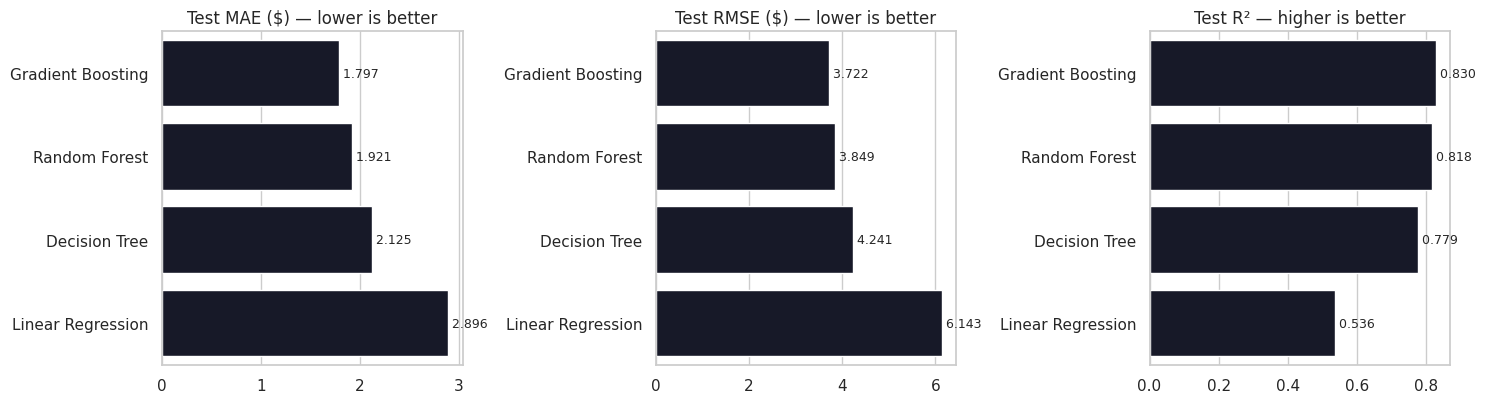

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
order = results.index
for ax, col, title in zip(axes, ['test_MAE', 'test_RMSE', 'test_R2'],
                          ['Test MAE ($) — lower is better', 'Test RMSE ($) — lower is better', 'Test R² — higher is better']):
    sns.barplot(x=results.loc[order, col].values, y=list(order), ax=ax, color='#14172b')
    ax.set_title(title); ax.set_xlabel(''); ax.set_ylabel('')
    for i, v in enumerate(results.loc[order, col].values):
        ax.text(v, i, f' {v:.3f}', va='center', fontsize=9)
plt.tight_layout(); plt.show()


## 5. Choosing the model to deploy

Selection rule (decided by **test-set** evidence, not training error):

1. Find the model with the lowest test RMSE.
2. Any model within **2 %** of that RMSE counts as "metrics are close". Among those, prefer the more
   **interpretable** one, then the **faster** one at prediction time.

The justification below is generated from the actual numbers; read it and edit the wording if you like.


In [9]:
INTERPRETABILITY = {'Linear Regression': 1, 'Decision Tree': 2, 'Gradient Boosting': 3, 'Random Forest': 3}

best_name = results['test_RMSE'].idxmin()
band = results[results['test_RMSE'] <= results.loc[best_name, 'test_RMSE'] * 1.02].copy()
band['interp'] = [INTERPRETABILITY[m] for m in band.index]
chosen = band.sort_values(['interp', 'predict_ms_per_1000']).index[0]
r = results.loc[chosen]

gap = (r['test_RMSE'] - r['train_RMSE']) / r['train_RMSE'] * 100
sentences = [
    f"I am deploying the {chosen}, which scored a test-set MAE of ${r['test_MAE']:.2f}, RMSE of ${r['test_RMSE']:.2f} and R² of {r['test_R2']:.3f}.",
]
if chosen == best_name:
    runner = results.drop(chosen).iloc[0]
    sentences.append(f"It had the lowest test RMSE of all four models; the next best ({results.drop(chosen).index[0]}) reached ${runner['test_RMSE']:.2f}.")
else:
    sentences.append(f"The lowest test RMSE belonged to {best_name} (${results.loc[best_name, 'test_RMSE']:.2f}), but {chosen} is within 2% of it, so I preferred the simpler / faster model.")
sentences.append(f"Its test RMSE is {abs(gap):.0f}% {'higher' if gap >= 0 else 'lower'} than its training RMSE (${r['train_RMSE']:.2f}), so the decision rests on unseen-data performance rather than a memorised fit.")
sentences.append(f"Scoring 1,000 trips takes about {r['predict_ms_per_1000']:.0f} ms, which is fast enough for a real-time Flask endpoint.")
if chosen == 'Linear Regression':
    sentences.append("Linear models are also fully interpretable: each coefficient shows how a feature moves the (log) fare.")
elif chosen == 'Decision Tree':
    sentences.append("A single tree is easy to inspect and explain, which matters when the metrics are close.")
else:
    sentences.append("Tree ensembles are harder to interpret than a linear model, but feature importances still show which inputs drive the fare.")

justification = ' '.join(sentences)
print('Chosen model:', chosen, '\n')
print(justification)


Chosen model: Gradient Boosting 

I am deploying the Gradient Boosting, which scored a test-set MAE of $1.80, RMSE of $3.72 and R² of 0.830. It had the lowest test RMSE of all four models; the next best (Random Forest) reached $3.85. Its test RMSE is 16% higher than its training RMSE ($3.22), so the decision rests on unseen-data performance rather than a memorised fit. Scoring 1,000 trips takes about 7 ms, which is fast enough for a real-time Flask endpoint. Tree ensembles are harder to interpret than a linear model, but feature importances still show which inputs drive the fare.


**Written justification (edit if you want to add your own observations):**

*Paste or adapt the text printed above (3–5 sentences) here before submitting.*


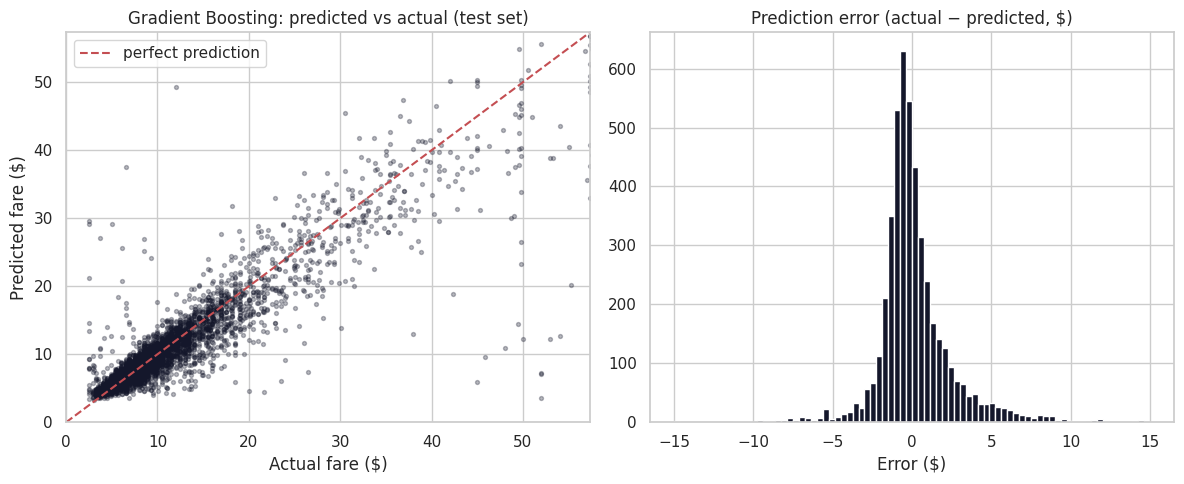

In [10]:
best_pipe = fitted[chosen]
pred = best_pipe.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, pred, s=8, alpha=0.3, color='#14172b')
lim = [0, float(np.percentile(y_test, 99.5))]
axes[0].plot(lim, lim, 'r--', label='perfect prediction'); axes[0].set_xlim(lim); axes[0].set_ylim(lim)
axes[0].set_xlabel('Actual fare ($)'); axes[0].set_ylabel('Predicted fare ($)')
axes[0].set_title(f'{chosen}: predicted vs actual (test set)'); axes[0].legend()

axes[1].hist(y_test - pred, bins=80, range=(-15, 15), color='#14172b')
axes[1].set_title('Prediction error (actual − predicted, $)'); axes[1].set_xlabel('Error ($)')
plt.tight_layout(); plt.show()


## 6. Part B — Save the model and preprocessing objects

The saved object is the **entire fitted Pipeline** (winsorizer + ordinal/one-hot encoders + RobustScaler +
regressor + log-target wrapper), so raw feature rows can be fed straight in. The fitted preprocessor is also
saved on its own, which is the "scaler / encoder" file the task asks for. `model_meta.json` stores the dropdown
categories, the training year range and the bearing convention for the Flask app.


In [11]:
joblib.dump(best_pipe, 'uber_fare_model.pkl', compress=3)
joblib.dump(best_pipe.named_steps['preprocessor'], 'uber_fare_preprocessor.pkl', compress=3)

meta = {
    'model_name': chosen,
    'bearing_convention': BEARING_CONVENTION,
    'categories': {
        'Weather': sorted(X_train['Weather'].unique().tolist()),
        'Traffic Condition': sorted(X_train['Traffic Condition'].unique().tolist()),
        'Car Condition': up.CAR_CONDITION_ORDER,
    },
    'year_range': [int(X_train['year'].min()), int(X_train['year'].max())],
    'feature_columns': up.FEATURE_COLUMNS,
    'test_metrics': {k: float(v) for k, v in r[['test_MAE', 'test_RMSE', 'test_R2']].items()},
    'justification': justification,
}
with open('model_meta.json', 'w') as f:
    json.dump(meta, f, indent=2)

for fn in ['uber_fare_model.pkl', 'uber_fare_preprocessor.pkl', 'model_meta.json']:
    print(f'{fn:<30} {os.path.getsize(fn) / 1e6:8.2f} MB')


uber_fare_model.pkl                0.17 MB
uber_fare_preprocessor.pkl         0.00 MB
model_meta.json                    0.00 MB


### Reload test — the saved file must reproduce the in-memory predictions exactly

In [12]:
reloaded = joblib.load('uber_fare_model.pkl')
sample_rows = X_test.head(10)
assert np.allclose(reloaded.predict(sample_rows), best_pipe.predict(sample_rows)), 'Saved model differs!'
print('OK — reloaded pipeline matches in-memory predictions.')

# Raw-input smoke test: exactly what the Flask app does with one submitted form
raw_trip = pd.DataFrame([{
    'pickup_datetime': '2014-06-15 18:30', 'pickup_latitude': 40.7580, 'pickup_longitude': -73.9855,
    'dropoff_latitude': 40.6413, 'dropoff_longitude': -73.7781, 'passenger_count': 1,
    'Car Condition': 'Good', 'Weather': meta['categories']['Weather'][0],
    'Traffic Condition': meta['categories']['Traffic Condition'][0],
}])
fare = reloaded.predict(up.add_features(raw_trip, BEARING_CONVENTION))[0]
print(f'Times Square -> JFK, 1 passenger: predicted fare ${fare:.2f}')


OK — reloaded pipeline matches in-memory predictions.
Times Square -> JFK, 1 passenger: predicted fare $40.52


## Next: run the Flask app (Parts C & D)

```bash
pip install -r requirements.txt
python app.py        # then open http://127.0.0.1:5000
```
See `README.md` for the test cases to screenshot.
